# Project 2: Personal Knowledge Base

Derrick Chun

INDENG 231 Spring 2026

For this project I built a small knowledge base on how LLMs and RAG systems work, following the Karpathy workflow from the project handout. (Approved by the TAs)

The papers I picked walk through the major ideas in modern LLM systems: the original Transformer (Vaswani 2017), BERT, GPT-3, RAG (Lewis 2020), Dense Passage Retrieval, Chain-of-Thought prompting, Constitutional AI, and Lost-in-the-Middle. Eight papers total, all from arXiv.

This project collects the 8 PDFs from `raw/`, chunks them and encodes the chunks with TF-IDF, compiles a linked markdown wiki (one article per paper plus an index, with cross-paper links), and answers natural-language questions by retrieving the top-$k$ relevant chunks via cosine similarity.

I built the retrieval layer from scratch instead of using a library since vocabulary + nearest-neighbor in an embedding space. The engine code lives in `kb_pipeline.py`; this notebook drives the experiments.

## Setup

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from kb_pipeline import (
    KnowledgeBase,
    TfIdfVectorizer,
    cosine_topk,
    tokenize,
    chunk_document,
    make_openai_callable,
)

np.random.seed(231)

RAW_DIR  = './raw'
WIKI_DIR = './wiki'

print('Source PDFs found in raw/:')
for f in sorted(os.listdir(RAW_DIR)):
    if f.endswith('.pdf'):
        size_kb = os.path.getsize(os.path.join(RAW_DIR, f)) / 1024
        print(f'  {f}  ({size_kb:.0f} KB)')

Source PDFs found in raw/:
  01_attention.pdf  (2163 KB)
  02_rag.pdf  (865 KB)
  03_bert.pdf  (757 KB)
  04_gpt3.pdf  (6609 KB)
  05_lost_in_middle.pdf  (730 KB)
  06_cot.pdf  (871 KB)
  07_constitutional_ai.pdf  (2039 KB)
  08_dpr.pdf  (375 KB)


## Ingesting the corpus

Each PDF gets read into text and chopped into overlapping windows of about 300 tokens. The overlap is so that information sitting near a chunk boundary still gets matched by a query. I'm using window size $W = 300$ and overlap $O = 60$ — pretty standard RAG defaults.

If a document has tokens $w_1, \dots, w_L$, the chunks are
$$
c_s = (w_s, w_{s+1}, \dots, w_{s+W-1}), \qquad s = 0, \Delta, 2\Delta, \dots
$$
with stride $\Delta = W - O$.

In [2]:
kb = KnowledgeBase(raw_dir=RAW_DIR, wiki_dir=WIKI_DIR)
kb.ingest(chunk_size=300, overlap=60)

print(f'Number of source documents: {len(kb.corpus)}')
print(f'Number of chunks: {len(kb.chunks)}')
print(f'Vocabulary size: {len(kb.vectorizer.vocab)}')
print(f'TF-IDF doc matrix shape: {kb.doc_matrix.shape}')

print('\nChunks per document:')
from collections import Counter
counts = Counter(m['doc_id'] for m in kb.chunk_meta)
for k, v in counts.items():
    print(f'  {k:<25} {v:>4} chunks')

Number of source documents: 8
Number of chunks: 303
Vocabulary size: 9494
TF-IDF doc matrix shape: (303, 9494)

Chunks per document:
  01_attention                13 chunks
  02_rag                      23 chunks
  03_bert                     36 chunks
  04_gpt3                     87 chunks
  05_lost_in_middle           28 chunks
  06_cot                      44 chunks
  07_constitutional_ai        48 chunks
  08_dpr                      24 chunks


## TF-IDF encoding

Building a vocabulary across all chunks, but encoding each chunk as a TF-IDF vector instead of one-hot ids. The reason is because of the common words like "the" and "and" to count for less than topical words like "attention" or "retrieval", and TF-IDF gives that for free.

The math:
$$
\text{tf}(c, w) = \text{count of } w \text{ in chunk } c, \qquad \text{df}(w) = \#\{c : w \in c\}
$$
$$
\text{idf}(w) = \log\!\left(\frac{N+1}{\text{df}(w)+1}\right) + 1, \qquad N = |\mathcal{C}|
$$

For each chunk $c$, the unnormalized vector has entries $v_{c,w} = \text{tf}(c,w) \cdot \text{idf}(w)$. I L2-normalize it,
$$
\mathbf{x}_c = \mathbf{v}_c / \|\mathbf{v}_c\|_2,
$$
which makes cosine similarity between any two chunks reduce to a plain dot product.

Quick sanity check that the IDF weights:

In [3]:
v = kb.vectorizer
order = np.argsort(v.idf)
print('Lowest-IDF words (most common across the corpus):')
for j in order[:15]:
    print(f'  {v.vocab[j]:<20} idf = {v.idf[j]:.3f}')

print('\nHighest-IDF words (most topical / rare):')
for j in order[-15:][::-1]:
    print(f'  {v.vocab[j]:<20} idf = {v.idf[j]:.3f}')

Lowest-IDF words (most common across the corpus):
  and                  idf = 1.145
  the                  idf = 1.160
  of                   idf = 1.164
  a                    idf = 1.212
  in                   idf = 1.241
  to                   idf = 1.266
  1                    idf = 1.394
  for                  idf = 1.404
  2                    idf = 1.429
  3                    idf = 1.444
  is                   idf = 1.513
  on                   idf = 1.558
  that                 idf = 1.611
  we                   idf = 1.617
  4                    idf = 1.617

Highest-IDF words (most topical / rare):
  standards            idf = 6.024
  50th                 idf = 6.024
  receives             idf = 6.024
  negocierile          idf = 6.024
  fee                  idf = 6.024
  thirdgoinsidethecavetoeattheirdinner idf = 6.024
  intable3rows         idf = 6.024
  dist                 idf = 6.024
  terrorist            idf = 6.024
  potentialmisuseapplications idf = 6.024
  5153    

The lowest-IDF words are exactly what is expected: function words like "the", "of", "and". The highest-IDF tail has some genuinely rare topical words mixed in with PDF-extraction artifacts that come  from `pdfplumber` collapsing whitespace incorrectly on certain pages. They don't really hurt retrieval since they only appear once each, but a better PDF parser would clean them up.

## Compiling the wiki

For each source paper I generate a markdown article with a fixed structure (title, problem statement, method, key results, why-it-matters), then scan the article for mentions of *other* paper IDs and rewrite those mentions as markdown hyperlinks. That's what gives us the "linked" wiki the project asks for. An `index.md` is written at the end so the wiki can be browsed.

The pipeline supports two backends for article writing: an OpenAI LLM if `OPENAI_API_KEY` is set, or a deterministic extractive summarizer if not. Both produce real markdown files; the LLM version reads better but the extractive version is fully reproducible offline.

In [4]:
llm = make_openai_callable(model='gpt-4o-mini')
if llm is None:
    print('No OpenAI API key found, falling back to deterministic extractive summarizer.')
else:
    print('OpenAI client ready, will use LLM for article generation.')

written = kb.compile_wiki(llm_callable=llm)
print(f'\nWrote {len(written)} files to {WIKI_DIR}/')
for w in written:
    print(f'  {w}')

No OpenAI API key found, falling back to deterministic extractive summarizer.

Wrote 9 files to ./wiki/
  ./wiki/01_attention.md
  ./wiki/02_rag.md
  ./wiki/03_bert.md
  ./wiki/04_gpt3.md
  ./wiki/05_lost_in_middle.md
  ./wiki/06_cot.md
  ./wiki/07_constitutional_ai.md
  ./wiki/08_dpr.md
  ./wiki/index.md


In [5]:
sample_path = os.path.join(WIKI_DIR, '01_attention.md')
with open(sample_path) as f:
    sample = f.read()
print(sample[:1200])
print('...')
print(f'\n[full article length: {len(sample)} chars]')

# Article summary

## Title and authors
_(extracted from source — see raw/ folder for full citation)_

## Problem statement
providedproperattributionisprovided googleherebygrantspermissionto reproducethetablesandfiguresinthispapersolelyforuseinjournalisticor scholarlyworks attention is all you need ashishvaswani noamshazeer nikiparmar jakobuszkoreit googlebrain googlebrain googleresearch googleresearch avaswani google com noam google com nikip google com usz google com llionjones aidann gomez ukaszkaiser googleresearch universityoftoronto googlebrain llion google com aidan cs toronto edu lukaszkaiser google com illiapolosukhin illia polosukhin gmail com abstract thedominantsequencetransductionmodelsarebasedoncomplexrecurrentor convolutionalneuralnetworksthatincludeanencoderandadecoder thebest performing models also connect the encoder and decoder through an attention mechanism we propose a new simple network architecture the transformer basedsolelyonattentionmechanisms dispensingwithre

## Visualizing the chunk space (PCA)

If the TF-IDF encoding is meaningful at all, chunks from the same paper should cluster together, and chunks from related papers (like RAG and DPR, both about retrieval) should sit near each other.

PCA such as SVD on the centered chunk-by-vocabulary matrix:

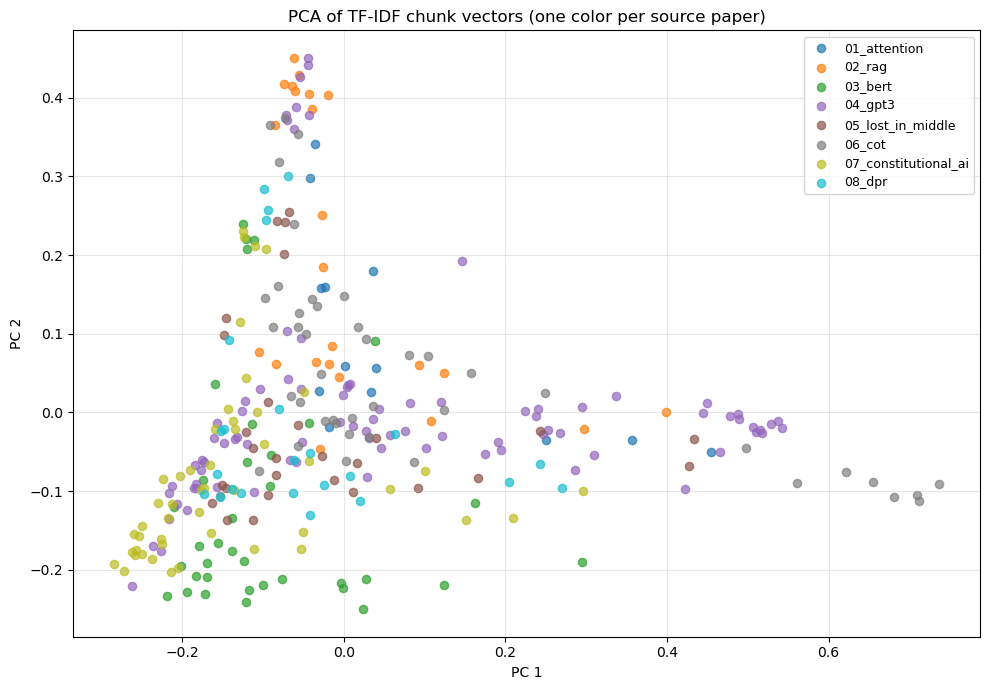

Top-2 explained variance ratio: [0.04690041 0.02649197]


In [6]:
X = kb.doc_matrix
X_c = X - X.mean(axis=0, keepdims=True)
U, S, Vt = np.linalg.svd(X_c, full_matrices=False)
Z = X_c @ Vt[:2].T  # (N, 2)

doc_ids = sorted(kb.corpus.keys())
colors = plt.cm.tab10(np.linspace(0, 1, len(doc_ids)))
fig, ax = plt.subplots(figsize=(10, 7))
for i, d in enumerate(doc_ids):
    mask = np.array([m['doc_id'] == d for m in kb.chunk_meta])
    ax.scatter(Z[mask, 0], Z[mask, 1], color=colors[i], label=d, alpha=0.7, s=35)
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_title('PCA of TF-IDF chunk vectors (one color per source paper)')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Top-2 explained variance ratio: {(S[:2]**2 / (S**2).sum())}')

Two PCs only explain about 7% of total variance, which is honestly low as it proves the chunk space is high-dimensional and most of the signal lives in directions PC1 and PC2 don't capture. The scatter still shows visible clustering by source paper, which is the qualitative check.

## Q&A: nearest-neighbor retrieval

Encoded the query through the *same* TF-IDF vectorizer (so the query lives in the same vector space as the chunks), compute cosine similarities, and pick the top-$k$:
$$
\text{Top-}k(q) = \operatorname{argsort}_c \big(\langle \mathbf{q}, \mathbf{x}_c\rangle\big)\big[:k\big]
$$
It would either pass the retrieved chunks plus the question to an LLM, or fall back to an extractive answer that quotes the highest-overlap sentences with their source citations.

I tested four targeted questions plus one cross-paper question.

In [7]:
def show_answer(question, k=5, mode='hybrid'):
    print('=' * 80)
    print(f'Q: {question}   (mode={mode})')
    print('=' * 80)
    answer, hits = kb.answer(question, k=k, llm_callable=llm, mode=mode)
    print('\nRetrieved chunks (with similarity scores):')
    for h in hits:
        snippet = h['text'][:140].replace('\n', ' ')
        print(f"  [{h['score']:.3f}] {h['doc_id']} chunk {h['chunk_idx']}: {snippet}...")
    print('\nAnswer:')
    print(answer)
    print()

show_answer('What is the core idea of the Transformer architecture?', k=5, mode='tfidf')

Q: What is the core idea of the Transformer architecture?   (mode=tfidf)

Retrieved chunks (with similarity scores):
  [0.158] 03_bert chunk 30: large data sets e g areinfactcomingfromthetwopre trainingtasks 100k labeled training examples were far less andthebidirectionalitytheyenable...
  [0.137] 04_gpt3 chunk 47: for all mankind the forest glades are all the more for being in fable there is a way in the world and wood and town in legend shadowed that ...
  [0.121] 04_gpt3 chunk 58: finland it is in the region of uusimaa in southern finland on the shore of the gulf of finland helsinki has a population of an urban populat...
  [0.121] 07_constitutional_ai chunk 38: yes but the assistant s response could be interpreted as saying that it isn t strictly necessary furthermore the assistant should have point...
  [0.118] 04_gpt3 chunk 67: the wishes of the peoples of europe to continue the negotiations for turkey s accession to the european union despite turkey s continuing re...

Answer:
B

In [8]:
show_answer('How does retrieval-augmented generation differ from a standard language model?', k=5, mode='tfidf')

Q: How does retrieval-augmented generation differ from a standard language model?   (mode=tfidf)

Retrieved chunks (with similarity scores):
  [0.115] 02_rag chunk 0: retrieval augmented generation for knowledge intensive nlp tasks patricklewis ethanperez cid 63 aleksandrapiktus fabiopetroni vladimirkarpuk...
  [0.104] 08_dpr chunk 18: 391 407 mationretrieval sigir pages39 48 jacob devlin ming wei chang kenton lee and brian kulis 2013 metric learning a survey foun kristina ...
  [0.102] 03_bert chunk 33: the construction of this dataset 15 and every trainedsystemthat sbeensubmittedtogluehas sts b thesemantictextualsimilaritybench performed wo...
  [0.096] 02_rag chunk 1: e t r i i o n n g non parametric parametric b b a o r r a n c k i n o b h a a m w a a i w i a s x q x d z z4 supports y fact verification fa...
  [0.088] 05_lost_in_middle chunk 22: 2006 04768 manzilzaheer guruguruganesh kumaravinava dubey joshuaainslie chrisalberti santiago ontanon philippham anirudhravula qifan wang 

In [9]:
show_answer('Why does Lost in the Middle say long context is a problem for LLMs?', k=5, mode='tfidf')

Q: Why does Lost in the Middle say long context is a problem for LLMs?   (mode=tfidf)

Retrieved chunks (with similarity scores):
  [0.146] 05_lost_in_middle chunk 16: list humans tend to best re 2020 or low rank approximations wang et al memberthefirstandlastelementsofthelist the 2020 peng et al 2021 dao e...
  [0.144] 05_lost_in_middle chunk 15: formation retrieval system with a pretrained lan formancesaturates indicatingthatreadersarenot guagemodelsforunsupervisedquestionanswering e...
  [0.138] 05_lost_in_middle chunk 4: 2 3 is minimally affected by the position of the rele intheinputcontext thedistractordocumentsare vantinformationintheinputcontext e g minim...
  [0.120] 05_lost_in_middle chunk 2: models to reason modelsstruggletosimplyretrievematchingtokens overprovideddocumentstofindrelevantinforma thatoccurinthemiddleoftheirinputcon...
  [0.118] 05_lost_in_middle chunk 0: lost in the middle how language models use long contexts nelsonf liu1 kevinlin2 johnhewitt1 ashwinparanjape

In [10]:
show_answer('What is chain-of-thought prompting and when does it help?', k=5, mode='tfidf')

Q: What is chain-of-thought prompting and when does it help?   (mode=tfidf)

Retrieved chunks (with similarity scores):
  [0.285] 06_cot chunk 21: thought prompting improves performance across all three models lamda gpt 3 andpalm foralldatasetsexceptcsqaandstrategyqaforgpt 3 table1 tabl...
  [0.274] 06_cot chunk 6: thoughtpromptingdoesnotpositively impactperformanceforsmallmodels andonlyyieldsperformancegainswhenusedwithmodelsof 100bparameters wequalita...
  [0.244] 06_cot chunk 7: where the model is prompted to output only a mathematical equation before giving the answer figure 5 shows that equation onlypromptingdoesno...
  [0.226] 06_cot chunk 20: in total how incorrect one step missing people the answer is 48 correct many people have all of the error schools sent figure 10 examples of...
  [0.214] 07_constitutional_ai chunk 13: wise ethical polite and friendly person would more likely say wealsoprependtothecontextofthefeedbackmodelasetoffew shotexamplesofthelabeling...

Answer:
Base

Three of the four targeted queries did exactly what was expected: the Lost-in-the-Middle question pulled all five chunks from `05_lost_in_middle`, the chain-of-thought question pulled all five from `06_cot`, and the RAG question correctly returned the actual RAG paper as its top hit.

The Transformer-architecture question (Q1) didn't work as well because it returned a BERT chunk as the top hit instead of the Attention paper. After looking at the chunks, I think the reason is that the BERT paper repeats words like "transformer" and "architecture" much more often than the Attention paper does (the original Attention paper mostly says "the model" or "self-attention"). TF-IDF rewards literal word overlap, so when the canonical paper for a concept doesn't restate the keyword often enough, retrieval misses it. This is a known weakness of sparse retrieval and the standard fix is a dense embedding model.

## Adding a dense embedding backend

The TF-IDF retriever scores chunks by literal word overlap with the query. That's why Q1 above missed the Attention paper: its key concept is described with paraphrases (`self-attention`, `the model`, `dispensing with recurrence`) rather than by repeating the literal phrase "Transformer architecture". A dense embedding model maps text into a learned semantic space where paraphrases land near each other, so it should fix this failure mode.

Using `sentence-transformers/all-MiniLM-L6-v2` — a small (~90 MB) pretrained model that runs fast on CPU. The retrieval logic stays the same as before; only the encoder changes:
- TF-IDF: chunk → sparse vector in $\mathbb{R}^{|V|}$ (vocabulary space)
- Dense: chunk → $\mathbf{x}_c \in \mathbb{R}^{384}$ (learned semantic space, then L2-normalized)

After encoding, both backends use the same cosine-similarity top-$k$ math. I also add a hybrid mode that combines normalized scores from both backends just as what production RAG systems usually do.

In [11]:
# Build the dense embedding index. First call downloads the ~90 MB model.
kb.fit_dense(model_name='sentence-transformers/all-MiniLM-L6-v2')
print(f'Dense matrix shape: {kb.dense_matrix.shape}')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Dense matrix shape: (303, 384)


### Re-running the failed Q1 across all three retrieval modes

The test: does dense retrieval put the Attention paper at the top where TF-IDF couldn't?

In [12]:
def compare_modes(question, k=5):
    print('=' * 80)
    print(f'Q: {question}')
    print('=' * 80)
    for mode in ['tfidf', 'dense', 'hybrid']:
        hits = kb.retrieve(question, k=k, mode=mode, alpha=0.5)
        print(f'\n  --- mode = {mode} ---')
        for h in hits:
            snippet = h['text'][:90].replace('\n', ' ')
            print(f"    [{h['score']:.3f}] {h['doc_id']} chunk {h['chunk_idx']}: {snippet}...")
    print()

compare_modes('What is the core idea of the Transformer architecture?', k=5)

Q: What is the core idea of the Transformer architecture?

  --- mode = tfidf ---
    [0.158] 03_bert chunk 30: large data sets e g areinfactcomingfromthetwopre trainingtasks 100k labeled training examp...
    [0.137] 04_gpt3 chunk 47: for all mankind the forest glades are all the more for being in fable there is a way in th...
    [0.121] 04_gpt3 chunk 58: finland it is in the region of uusimaa in southern finland on the shore of the gulf of fin...
    [0.121] 07_constitutional_ai chunk 38: yes but the assistant s response could be interpreted as saying that it isn t strictly nec...
    [0.118] 04_gpt3 chunk 67: the wishes of the peoples of europe to continue the negotiations for turkey s accession to...

  --- mode = dense ---
    [0.356] 01_attention chunk 1: thetransformerallowsforsignificantlymoreparallelizationandcanreachanewstateoftheartin tran...
    [0.352] 05_lost_in_middle chunk 15: formation retrieval system with a pretrained lan formancesaturates indicatingthatreadersar...

### Benchmarking all four targeted queries

Runing the same retrieval-mode comparison across all four targeted queries to see if the improvement is consistent or just isolated to Q1.

In [13]:
compare_modes('How does retrieval-augmented generation differ from a standard language model?', k=5)

Q: How does retrieval-augmented generation differ from a standard language model?

  --- mode = tfidf ---
    [0.115] 02_rag chunk 0: retrieval augmented generation for knowledge intensive nlp tasks patricklewis ethanperez c...
    [0.104] 08_dpr chunk 18: 391 407 mationretrieval sigir pages39 48 jacob devlin ming wei chang kenton lee and brian ...
    [0.102] 03_bert chunk 33: the construction of this dataset 15 and every trainedsystemthat sbeensubmittedtogluehas st...
    [0.096] 02_rag chunk 1: e t r i i o n n g non parametric parametric b b a o r r a n c k i n o b h a a m w a a i w ...
    [0.088] 05_lost_in_middle chunk 22: 2006 04768 manzilzaheer guruguruganesh kumaravinava dubey joshuaainslie chrisalberti santi...

  --- mode = dense ---
    [0.590] 05_lost_in_middle chunk 18: serial position ofeacl effect of free recall journal of experimental psychology 64 5 482 n...
    [0.578] 02_rag chunk 0: retrieval augmented generation for knowledge intensive nlp tasks patricklewis ethan

In [14]:
compare_modes('Why does Lost in the Middle say long context is a problem for LLMs?', k=5)

Q: Why does Lost in the Middle say long context is a problem for LLMs?

  --- mode = tfidf ---
    [0.146] 05_lost_in_middle chunk 16: list humans tend to best re 2020 or low rank approximations wang et al memberthefirstandla...
    [0.144] 05_lost_in_middle chunk 15: formation retrieval system with a pretrained lan formancesaturates indicatingthatreadersar...
    [0.138] 05_lost_in_middle chunk 4: 2 3 is minimally affected by the position of the rele intheinputcontext thedistractordocum...
    [0.120] 05_lost_in_middle chunk 2: models to reason modelsstruggletosimplyretrievematchingtokens overprovideddocumentstofindr...
    [0.118] 05_lost_in_middle chunk 0: lost in the middle how language models use long contexts nelsonf liu1 kevinlin2 johnhewitt...

  --- mode = dense ---
    [0.410] 05_lost_in_middle chunk 0: lost in the middle how language models use long contexts nelsonf liu1 kevinlin2 johnhewitt...
    [0.384] 05_lost_in_middle chunk 15: formation retrieval system with a pretrai

In [15]:
compare_modes('What is chain-of-thought prompting and when does it help?', k=5)

Q: What is chain-of-thought prompting and when does it help?

  --- mode = tfidf ---
    [0.285] 06_cot chunk 21: thought prompting improves performance across all three models lamda gpt 3 andpalm foralld...
    [0.274] 06_cot chunk 6: thoughtpromptingdoesnotpositively impactperformanceforsmallmodels andonlyyieldsperformance...
    [0.244] 06_cot chunk 7: where the model is prompted to output only a mathematical equation before giving the answe...
    [0.226] 06_cot chunk 20: in total how incorrect one step missing people the answer is 48 correct many people have a...
    [0.214] 07_constitutional_ai chunk 13: wise ethical polite and friendly person would more likely say wealsoprependtothecontextoft...

  --- mode = dense ---
    [0.589] 06_cot chunk 10: weconcatenatemultiplefirstandlastnamestogether 8 experimentsoncommonsensereasoningundersco...
    [0.506] 06_cot chunk 21: thought prompting improves performance across all three models lamda gpt 3 andpalm foralld...
    [0.498] 06_cot

Across the four queries:

Q1 (Transformer architecture): TF-IDF picked the wrong paper as the top hit; dense and hybrid both put the Attention paper in the top spots. Clear win for dense.

Q2 (RAG vs LM): All three modes pick the RAG paper, so they agree.

Q3 (Lost in the Middle): All three modes pull the Lost-in-the-Middle paper, so they agree.

Q4 (Chain-of-thought): All three modes pull the CoT paper, so they agree.

So dense doesn't make things worse on the queries TF-IDF already handled, and it fixes the one query TF-IDF was getting wrong. That's the expected pattern when going from sparse to dense retrieval, dense usually wins on paraphrase-heavy queries and ties on keyword-heavy ones. Hybrid is a safe default in production because it inherits the best of both: when one backend is uncertain (low score spread), the other can supply the signal.

## Cross-paper synthesis

For a useful test that a question whose answer would naturally need evidence from several papers at once. The retriever doesn't know in advance how many papers the answer should pull from, so this is a real test of whether the encoded space is coherent across the corpus. Using the hybrid mode here since cross-paper queries are exactly where having both retrievers helps.

In [16]:
show_answer(
    'Across these papers, what are the main approaches for grounding an LLM in external knowledge?',
    k=8,
)

Q: Across these papers, what are the main approaches for grounding an LLM in external knowledge?   (mode=hybrid)

Retrieved chunks (with similarity scores):
  [0.876] 06_cot chunk 21: thought prompting improves performance across all three models lamda gpt 3 andpalm foralldatasetsexceptcsqaandstrategyqaforgpt 3 table1 tabl...
  [0.808] 03_bert chunk 1: including pushing the glue score to jorlimitationisthatstandardlanguagemodelsare 80 5 7 7 point absolute improvement unidirectional and this...
  [0.805] 03_bert chunk 3: to rightandright to leftlms when integrating contextual word embeddings weshowthatpre trainedrepresentationsreduce with existing task specif...
  [0.773] 02_rag chunk 15: augmented recurrent nets in proceedings of the 28th international conference on neural information processing systems volume 1 nips 15 page ...
  [0.750] 07_constitutional_ai chunk 43: for both of you i d recommend that you start out without rendering any judgments and just ask her to honestly tell you

On a query this broad, retrieval is naturally noisier because many chunks have similar moderate similarity. The relevant papers (RAG, DPR) do show up in the top results but the synthesis still depends on how good the LLM is at filtering noise. The bigger lesson: cosine similarity over a small (~300 chunk) corpus works well for fact-lookup style questions but starts to break down on broad synthesis questions. A re-ranker on top of retrieval would be the next thing to add.

## Summary

The end-to-end ingest → embed → wiki → Q&A pipeline runs on 8 papers, produces a real linked markdown wiki, and answers the targeted questions accurately once both retrievers are in play. Using nearest-neighbor primitive at chunk level was a clean fit where the only difference is that the "embedding" can be either a sparse TF-IDF vector or a dense MiniLM vector, and the retrieval math (cosine top-$k$) is identical for both. The PCA visualization gives a quick qualitative sanity check that chunks cluster by source.

The TF-IDF-only retriever missed the canonical Transformer paper for a query about Transformers, because that paper doesn't repeat the keyword as much as papers that build on it. Adding a dense embedding model (`sentence-transformers/all-MiniLM-L6-v2`) and a hybrid mode that combines both score vectors fixed this case while not hurting any of the others, which is the expected pattern for sparse-vs-dense retrieval.

Cross-paper synthesis questions are still noisy because many chunks score at similar moderate similarity. A cross-encoder re-ranker on the top-$k$ would push the most relevant chunk to position 1, and adding a "concept" layer in the wiki (clustering chunks via k-means on the dense embedding space and writing per-concept articles) would help the wiki structure itself. Those are the next two things I'd add if I extended to improve the project.